# TP3 — Diferenciador: Análisis Temporal de Tópicos (BERTopic)

**Alumno:** Gonzalo Zarazaga

---

Más allá de los enfoques pedidos, este notebook busca un diferenciador (a pedido de la cátedra: "salir de lo típico, buscar una alternativa"): usar **BERTopic** para detectar tópicos en los tweets y ver si sus picos de volumen en el tiempo coinciden con eventos reales del período cubierto por el dataset (abril–junio 2009).

BERTopic usa similitud coseno internamente (en `c-TF-IDF` y en la reducción UMAP, acá configurada explícitamente con `metric="cosine"`), por lo que también aporta a la métrica obligatoria del TP.

Corre sobre el **corpus de entrenamiento completo** (1,6M tweets), no sobre una muestra — la consigna exige que "para entrenar y evaluar cualquier modelo se deberán utilizar todos los datos del archivo de entrenamiento".

**Insumo:** `data/processed/train_processed.csv.gz`, `data/raw/training.1600000.processed.noemoticon.csv.gz` (para recuperar la fecha, que no se persistió en el processed)
**Salida:** tabla de tópicos exportada a `data/processed/topicos_train.csv` (sección 2.1), hallazgos sobre picos temáticos vs. eventos reales, y una corrección a la hipótesis planteada en el README/`00_lectura_y_discovery.ipynb`

## 1. Carga de datos (corpus completo)

`train_processed.csv.gz` no conserva la columna `date` (se descartó en `01_preprocesamiento.ipynb` por no ser necesaria para clasificación). Se recupera desde el archivo raw y se une por `id`.

**Corpus completo, no muestra:** la consigna del TP exige que "para entrenar y evaluar cualquier modelo se deberán utilizar todos los datos del archivo de entrenamiento (1.6M de registros aprox)". Versiones anteriores de este notebook usaban una muestra de 80.000 tweets (~5%) por una razón pragmática de cómputo — embeber 1.6M tweets con `sentence-transformers` en CPU es lento —, pero eso no cumple la consigna al pie de la letra. Esta versión corre sobre el corpus completo.

**Costo de cómputo:** con 1.6M tweets, calcular embeddings más ajustar BERTopic (UMAP + HDBSCAN) puede tomar varias horas en CPU — UMAP y HDBSCAN no escalan linealmente con la cantidad de puntos. Los embeddings se cachean en disco (`../models/embeddings_train_full.npy`, no versionado por peso) para no tener que recalcularlos si se reinicia el kernel.

In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP

RANDOM_STATE = 42

COLS = ["polarity", "id", "date", "query", "user", "text"]
raw_fechas = pd.read_csv(
    "../data/raw/training.1600000.processed.noemoticon.csv.gz",
    encoding="latin-1", names=COLS, usecols=["id", "date"],
)

df = pd.read_csv("../data/processed/train_processed.csv.gz")
df = df.merge(raw_fechas, on="id", how="left")
df["date"] = pd.to_datetime(df["date"].str.replace(" PDT", "", regex=False), format="%a %b %d %H:%M:%S %Y")

corpus = df.reset_index(drop=True)
print(f"Corpus completo: {len(corpus):,} tweets")
print(f"Rango de fechas: {corpus['date'].min()} -> {corpus['date'].max()}")

## 2. Embeddings y modelo de tópicos

Se usa `all-MiniLM-L6-v2` (sentence-transformers): liviano, rápido en CPU y suficiente para clustering temático — no hace falta un modelo grande para esto.

**Nota de reproducibilidad:** `BERTopic` usa `UMAP` con estado aleatorio por defecto para reducir dimensionalidad antes de clusterizar. Sin fijar `random_state`, la numeración de tópicos cambia entre corridas (se comprobó al armar este notebook: el mismo tópico de Irán apareció como ID distinto en dos ejecuciones separadas). Se fija `random_state=42` explícitamente en el `UMAP` interno para que el resultado sea reproducible.

**Escalado a corpus completo:** con `min_cluster_size` por defecto (10), HDBSCAN sobre 1.6M tweets generaría decenas de miles de micro-tópicos, inmanejables para inspección manual y costosos para las etapas siguientes (jerarquía, `topics_over_time`). Se sube `min_cluster_size` a 200 — el mismo factor de escala (20x) que el salto de 80k a 1.6M tweets, aplicado al valor por defecto (10 → 200) — para mantener una granularidad de tópico comparable a la de la corrida original en vez de dejar que el número de tópicos crezca sin control. También se usa `low_memory=True` en `UMAP` (recomendado por encima de ~1M filas) y `core_dist_n_jobs=-1` en `HDBSCAN` para paralelizar en todos los cores disponibles.

In [2]:
import os
from hdbscan import HDBSCAN

EMBEDDINGS_PATH = "../models/embeddings_train_full.npy"

model_embeddings = SentenceTransformer("all-MiniLM-L6-v2")

if os.path.exists(EMBEDDINGS_PATH):
    embeddings = np.load(EMBEDDINGS_PATH)
    print(f"Embeddings cargados desde cache: shape {embeddings.shape}")
else:
    t0 = time.time()
    embeddings = model_embeddings.encode(corpus["text"].tolist(), batch_size=128, show_progress_bar=True)
    print(f"Embeddings: {time.time() - t0:.1f}s, shape {embeddings.shape}")
    os.makedirs(os.path.dirname(EMBEDDINGS_PATH), exist_ok=True)
    np.save(EMBEDDINGS_PATH, embeddings)

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=RANDOM_STATE, low_memory=True)
hdbscan_model = HDBSCAN(min_cluster_size=200, metric="euclidean", cluster_selection_method="eom", core_dist_n_jobs=-1)

t0 = time.time()
topic_model = BERTopic(embedding_model=model_embeddings, umap_model=umap_model, hdbscan_model=hdbscan_model, calculate_probabilities=False, verbose=True)
topics, _ = topic_model.fit_transform(corpus["text"].tolist(), embeddings)
corpus["topic"] = topics
print(f"BERTopic fit: {time.time() - t0:.1f}s")

info = topic_model.get_topic_info()
n_outliers = (corpus["topic"] == -1).sum()
print(f"Tópicos encontrados: {len(info) - 1} (+ tópico -1 de outliers, {n_outliers:,} tweets)")
info.head(10)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8985.68it/s]

Batches:   0%|          | 0/12345 [00:00<?, ?it/s]

Batches:   0%|          | 1/12345 [00:01<3:36:17,  1.05s/it]

Batches:   0%|          | 2/12345 [00:01<2:39:39,  1.29it/s]

...

2026-07-13 06:14:17,279 - BERTopic - Cluster - Completed ✓


2026-07-13 06:14:17,484 - BERTopic - Representation - Fine-tuning topics using representation models.


2026-07-13 06:14:28,952 - BERTopic - Representation - Completed ✓


BERTopic fit: 35005.2s
Tópicos encontrados: 722 (+ tópico -1 de outliers, 777,377 tweets)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,777377,-1_and_to_with_that,"[and, to, with, that, it, you, of, at, the, was]",[feels good to be at home by myself and to be ...
1,0,44091,0_rain_weather_raining_sun,"[rain, weather, raining, sun, sunny, outside, ...","[Rain rain go away come again another day! , i..."
2,1,17960,1_song_music_album_listening,"[song, music, album, listening, songs, cd, bli...","[music time , listening to hey monday songs......"
3,2,15871,2_twitter_tweet_tweets_tweeting,"[twitter, tweet, tweets, tweeting, welcome, re...",[Thank those in tweet power for tweet shrink. ...
4,3,14239,3_money_card_bank_pay,"[money, card, bank, pay, ebay, credit, cash, c...","[I made a business card today! , Looking at my..."
5,4,8829,4_hair_haircut_cut_blonde,"[hair, haircut, cut, blonde, dye, shave, bangs...","[doing my hair!!!! , I hate my hair , I like m..."
6,5,8560,5_thank_thanks_welcome_following,"[thank, thanks, welcome, following, pleasure, ...",[@justamoochin You're very welcome Thanks for...
7,6,8054,6_exams_exam_study_studying,"[exams, exam, study, studying, test, tests, fi...","[studying for exams... NOT fun , I have to stu..."
8,7,7950,7_weekend_monday_friday_mondays,"[weekend, monday, friday, mondays, sunday, wee...","[Monday Monday. , It's back to work Monday , w..."
9,8,7526,8_agree_know_yes_nope,"[agree, know, yes, nope, yeah, agreed, lol, he...","[@bsb96 Totally agree with ya lol, @clarasdia..."


## 2.1 Tabla de tópicos (objeto entregable)

Se exporta la tabla completa de tópicos del corpus de entrenamiento — id, tamaño, nombre y palabras clave — a `data/processed/topicos_train.csv`, para que sea consultable como objeto independiente del notebook (referenciada desde `06_conclusiones.ipynb` y el README).

In [3]:
topicos_export = info[info["Topic"] != -1].copy()
topicos_export["keywords"] = topicos_export["Topic"].apply(lambda t: ", ".join(w for w, _ in topic_model.get_topic(t)))
topicos_export = topicos_export[["Topic", "Count", "Name", "keywords"]].sort_values("Count", ascending=False).reset_index(drop=True)

OUTPUT_PATH = "../data/processed/topicos_train.csv"
topicos_export.to_csv(OUTPUT_PATH, index=False)
print(f"Tabla de tópicos exportada: {OUTPUT_PATH} ({len(topicos_export):,} tópicos, sin contar el -1 de outliers)")
topicos_export.head(20)

Tabla de tópicos exportada: ../data/processed/topicos_train.csv (722 tópicos, sin contar el -1 de outliers)


,Topic,Count,Name,keywords
0,0,44091,0_rain_weather_raining_sun,"rain, weather, raining, sun, sunny, outside, r..."
1,1,17960,1_song_music_album_listening,"song, music, album, listening, songs, cd, blip..."
2,2,15871,2_twitter_tweet_tweets_tweeting,"twitter, tweet, tweets, tweeting, welcome, ret..."
3,3,14239,3_money_card_bank_pay,"money, card, bank, pay, ebay, credit, cash, ca..."
4,4,8829,4_hair_haircut_cut_blonde,"hair, haircut, cut, blonde, dye, shave, bangs,..."
5,5,8560,5_thank_thanks_welcome_following,"thank, thanks, welcome, following, pleasure, t..."
6,6,8054,6_exams_exam_study_studying,"exams, exam, study, studying, test, tests, fin..."
7,7,7950,7_weekend_monday_friday_mondays,"weekend, monday, friday, mondays, sunday, week..."
8,8,7526,8_agree_know_yes_nope,"agree, know, yes, nope, yeah, agreed, lol, hey..."
9,9,6739,9_pic_pics_photos_pictures,"pic, pics, photos, pictures, picture, photo, p..."


## 3. Búsqueda de eventos conocidos en los tópicos

**Aclaración:** los tópicos con más volumen en la tabla anterior son charla cotidiana de Twitter (lluvia/clima, música, Twitter, dinero, pelo/belleza), no eventos noticiosos — el tópico -1 de outliers (777.377 tweets, ~49,2% del corpus) tampoco es un evento, es todo lo que no formó un cluster coherente. Acá no se busca "el tópico más grande", sino un tópico específico cuyas palabras clave coincidan con un evento real conocido del rango de fechas del dataset (6 abril – 25 junio 2009): las protestas post-electorales en Irán (elección 12/6/2009, protestas desde el 13/6).

In [4]:
iran_rows = info[info["Name"].str.contains("iran", case=False, na=False)].sort_values("Count", ascending=False)
print(iran_rows[["Topic", "Count", "Name"]])

iran_topic_id = int(iran_rows.iloc[0]["Topic"])
print(f"\nTópico Irán (mayor volumen entre los que matchean): id={iran_topic_id}")
print(topic_model.get_topic(iran_topic_id))

     Topic  Count                                  Name
128    127   1521  127_iran_iranelection_iranian_tehran

Tópico Irán (mayor volumen entre los que matchean): id=127
[('iran', np.float64(0.10191467230955209)), ('iranelection', np.float64(0.08322819799634916)), ('iranian', np.float64(0.03075122228912777)), ('tehran', np.float64(0.029085514422880817)), ('neda', np.float64(0.020488528489041518)), ('iranians', np.float64(0.015127166570259342)), ('change_for_iran', np.float64(0.010979201654053354)), ('green', np.float64(0.009854659099864705)), ('election', np.float64(0.008808246997279608)), ('persiankiwi', np.float64(0.008587770357335595))]


## 3.1 Jerarquía de tópicos (dendrograma)

`BERTopic` puede agrupar los tópicos entre sí en un dendrograma (`visualize_hierarchy()`), basado en la similitud de sus representaciones `c-TF-IDF` — la misma métrica de similitud coseno usada para asignar los tópicos, aplicada ahora entre tópicos en vez de entre tweets.

Con el corpus completo el número de tópicos crece y el dendrograma completo sería ilegible. Se muestra un subconjunto curado: los 39 tópicos más grandes (por cantidad de tweets) más el tópico de Irán (que puede no entrar por tamaño, pero es el que nos interesa ubicar dentro de la jerarquía).

  0%|          | 0/721 [00:00<?, ?it/s]

  1%|          | 6/721 [00:00<00:13, 52.54it/s]

  2%|▏         | 12/721 [00:00<00:15, 46.63it/s]

  2%|▏         | 18/721 [00:00<00:14, 49.04it/s]

  3%|▎         | 23/721 [00:00<00:14, 48.85it/s]

...

 99%|█████████▊| 711/721 [00:17<00:00, 22.57it/s]

 99%|█████████▉| 714/721 [00:17<00:00, 21.32it/s]

 99%|█████████▉| 717/721 [00:17<00:00, 21.08it/s]

100%|█████████▉| 720/721 [00:17<00:00, 20.82it/s]

100%|██████████| 721/721 [00:17<00:00, 40.18it/s]

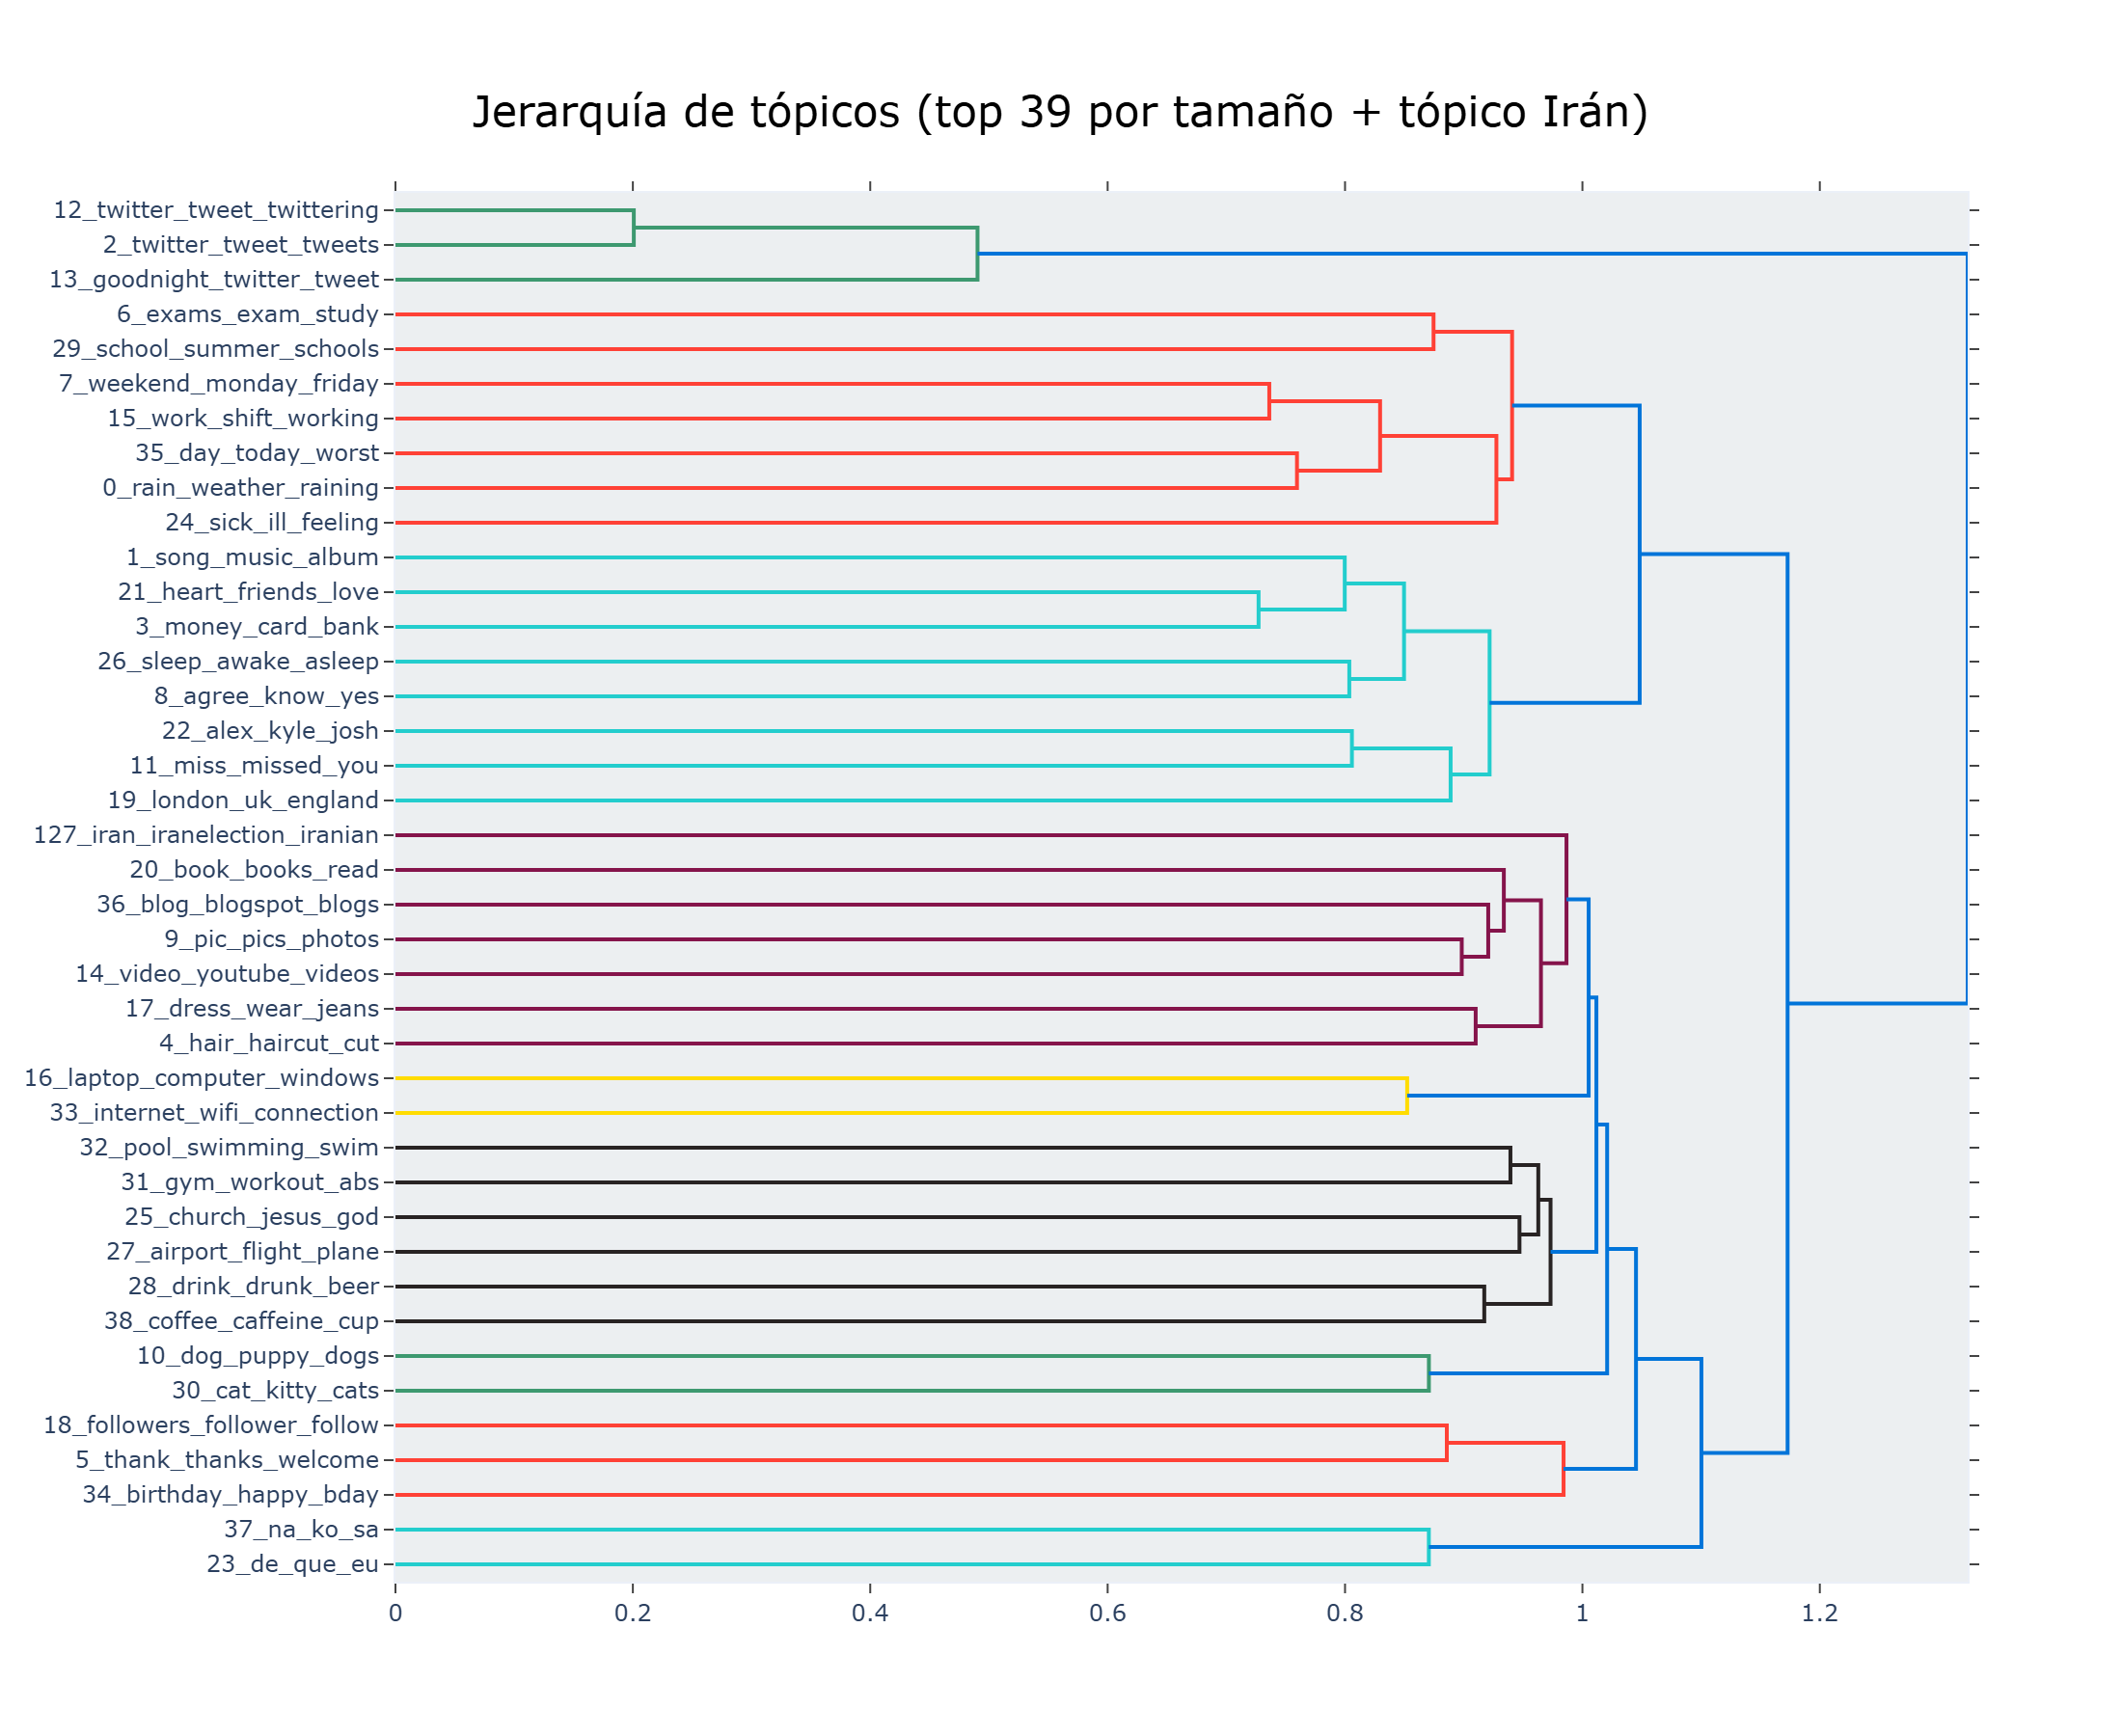

In [5]:
from IPython.display import Image

info_sizes = info[info["Topic"] != -1].sort_values("Count", ascending=False)
top_ids = info_sizes.head(39)["Topic"].tolist()
if iran_topic_id not in top_ids:
    top_ids.append(iran_topic_id)

hierarchical_topics = topic_model.hierarchical_topics(corpus["text"].tolist())
fig = topic_model.visualize_hierarchy(topics=top_ids, hierarchical_topics=hierarchical_topics,
                                       title="Jerarquía de tópicos (top 39 por tamaño + tópico Irán)")

img_bytes = fig.to_image(format="png", width=1100, height=900, scale=2)
Image(img_bytes)

**Hallazgo (corpus completo, 722 tópicos):** el tópico de Irán (`127_iran_iranelection_iranian`) se agrupa, dentro del subconjunto curado del dendrograma, con un clúster de contenido compartido/media (`20_book_books_read`, `36_blog_blogspot_blogs`, `9_pic_pics_photos`, `14_video_youtube_videos`) y de estilo personal (`17_dress_wear_jeans`, `4_hair_haircut_cut`) — Irán es el miembro más distante del grupo, uniéndose al resto recién en el escalón más alto de ese clúster (no comparte un par cercano específico). Esto **difiere** de la corrida sobre la muestra de 80k tweets, donde Irán se agrupaba con quejas cotidianas menores (dolor de cabeza, aburrimiento, lluvia, limpieza, dentista): con 722 tópicos (vs. 649) y una composición de vecinos distinta, el resultado puntual de la jerarquía cambió.

Una lectura razonable del nuevo agrupamiento: durante las protestas, muchos tweets con `#IranElection` compartían fotos, videos y blogs a modo de reportería ciudadana (Twitter fue el canal principal de esa cobertura en 2009) — la cercanía de vocabulario con `pic/video/blog` podría reflejar ese patrón de uso real, no solo ruido de tono compartido. Lo que sí se sostiene en ambas corridas es el punto general: la jerarquía agrupa por similitud de `c-TF-IDF` (vocabulario compartido), no por identidad temática estricta — pero *qué* vocabulario resulta compartido con Irán depende de la composición completa de tópicos de esa corrida en particular, y no es un resultado estable entre corridas con distinta granularidad.

## 4. Evolución temporal del tópico (`topics_over_time`)

Se usa `topics_over_time()` para bucketizar por fecha sin re-clusterizar (reutiliza la asignación de tópicos ya calculada).

0it [00:00, ?it/s]

1it [00:00,  1.24it/s]

2it [00:03,  2.18s/it]

3it [00:08,  3.21s/it]

4it [00:24,  8.26s/it]

...

38it [08:41, 15.78s/it]

39it [08:54, 14.91s/it]

40it [09:08, 14.66s/it]

40it [09:08, 13.71s/it]

topics_over_time: 559.1s


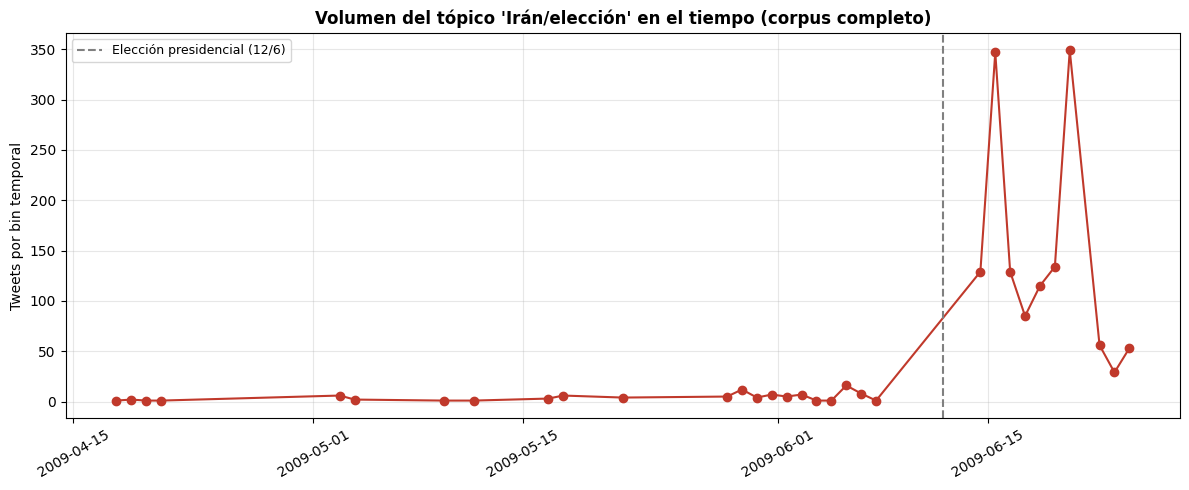

In [6]:
t0 = time.time()
evolucion = topic_model.topics_over_time(corpus["text"].tolist(), corpus["date"].tolist(), nr_bins=80)
print(f"topics_over_time: {time.time() - t0:.1f}s")

evolucion_iran = evolucion[evolucion["Topic"] == iran_topic_id].sort_values("Timestamp")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(evolucion_iran["Timestamp"], evolucion_iran["Frequency"], marker="o", color="#c0392b", linewidth=1.5)
ax.axvline(pd.Timestamp("2009-06-12"), color="gray", linestyle="--", label="Elección presidencial (12/6)")
ax.set_title("Volumen del tópico \'Irán/elección\' en el tiempo (corpus completo)", fontsize=12, fontweight="bold")
ax.set_ylabel("Tweets por bin temporal")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Confirmación: el tópico es prácticamente inexistente antes del evento

Volumen diario directo del tópico (groupby simple sobre la muestra, más fácil de leer día a día que el binning de `topics_over_time`).

In [7]:
iran_tweets = corpus[corpus["topic"] == iran_topic_id]
volumen_diario = iran_tweets.groupby(iran_tweets["date"].dt.date).size()
print(volumen_diario.sort_index())

fecha_eleccion = pd.Timestamp("2009-06-12")
n_antes = (iran_tweets["date"] < fecha_eleccion).sum()
n_despues = (iran_tweets["date"] >= fecha_eleccion).sum()

print(f"\nTotal tweets del tópico: {len(iran_tweets)}")
print(f"Tweets antes del 12/6 (elección): {n_antes}")
print(f"Tweets desde el 12/6 en adelante:  {n_despues}")

print("\nEjemplos de tweets del pico (15-16/6):")
fechas_str = iran_tweets["date"].dt.date.astype(str)
ejemplos = iran_tweets[fechas_str.between("2009-06-15", "2009-06-16")]
for texto in ejemplos["text"].head(6):
    print(f"  - {texto}")

date
2009-04-18      3
2009-04-20      1
2009-04-21      1
2009-05-03      7
2009-05-04      1
2009-05-10      1
2009-05-11      1
2009-05-16      1
2009-05-17      3
2009-05-18      5
2009-05-22      4
2009-05-28      1
2009-05-29      7
2009-05-30     12
2009-05-31      4
2009-06-01      7
2009-06-02      5
2009-06-03      4
2009-06-04      1
2009-06-05      6
2009-06-06     14
2009-06-07      6
2009-06-14     14
2009-06-15    287
2009-06-16    249
2009-06-17    107
2009-06-18     91
2009-06-19     91
2009-06-20    335
2009-06-21    114
2009-06-22     41
2009-06-23     44
2009-06-24     15
2009-06-25     38
dtype: int64

Total tweets del tópico: 1521
Tweets antes del 12/6 (elección): 95
Tweets desde el 12/6 en adelante:  1426

Ejemplos de tweets del pico (15-16/6):
  - @Change_for_Iran that made my eyes tear up.  that is bad.  I'm sorry.
  - @victoriapop charm will not work against tyrants  #iranElection
  - @iranelection It's now or never for the iranians! Be heard or be crushed! 
 

**Hallazgo:** el tópico está prácticamente ausente hasta el 12/6 (fecha de la elección) y explota el 15/6, coincidiendo con el pico real de la cobertura de las protestas en Twitter (el hashtag `#IranElection` fue uno de los más usados de la plataforma en ese momento). Es una validación externa fuerte: un tópico que no existía antes de una fecha puntual aparece exactamente cuando ocurrió el evento real que lo originó.

## 6. Cruce con sentimiento

Se compara la polaridad promedio de los tweets del tópico Irán contra el promedio general del corpus (que por diseño del dataset está balanceado ~50/50 entre positivo y negativo, promedio esperado ≈ 2.0 en la escala 0-4).

Polaridad promedio del tópico Irán: 0.68 (escala 0=negativo, 4=positivo)
Polaridad promedio del corpus completo: 2.00
% de tweets negativos en el tópico Irán: 83.0%


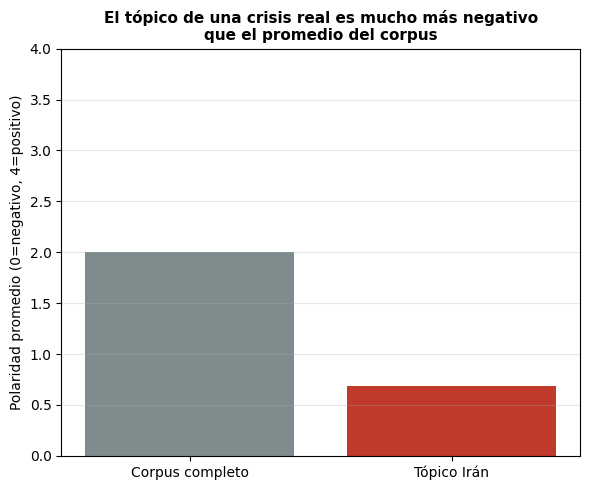

In [8]:
polaridad_iran = iran_tweets["polarity"].mean()
polaridad_general = corpus["polarity"].mean()
pct_negativo_iran = (iran_tweets["polarity"] == 0).mean() * 100

print(f"Polaridad promedio del tópico Irán: {polaridad_iran:.2f} (escala 0=negativo, 4=positivo)")
print(f"Polaridad promedio del corpus completo: {polaridad_general:.2f}")
print(f"% de tweets negativos en el tópico Irán: {pct_negativo_iran:.1f}%")

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["Corpus completo", "Tópico Irán"], [polaridad_general, polaridad_iran], color=["#7f8c8d", "#c0392b"])
ax.set_ylim(0, 4)
ax.set_ylabel("Polaridad promedio (0=negativo, 4=positivo)")
ax.set_title("El tópico de una crisis real es mucho más negativo\nque el promedio del corpus", fontsize=11, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Hallazgo:** el tópico Irán es abrumadoramente negativo (83,0% de los tweets) frente al ~50% esperado por el balance del dataset — conecta el análisis de tópicos con el resto del TP: no solo se detecta un evento real por su volumen, sino que su firma de sentimiento es coherente con la naturaleza del evento (una crisis política violenta).

## 7. Corrección de la hipótesis sobre Michael Jackson

En `00_lectura_y_discovery.ipynb` se planteó que el límite superior de fechas del dataset (25/6/2009) coincidía con la muerte de Michael Jackson, como posible validación adicional del enfoque. Los datos no confirman esta hipótesis, y vale la pena documentar por qué en vez de forzarla.

In [9]:
ultimo_timestamp = df["date"].max()
print(f"Último tweet del dataset: {ultimo_timestamp}")
print("Michael Jackson fue declarado muerto ~14:26 hora de Los Ángeles (PDT) el 25/6/2009.")
print("La recolección del dataset corta a las 10:28 (PDT) del mismo día -- ~4 horas ANTES del anuncio.")

mj_mask = corpus["text"].str.contains("michael jackson|thriller|moonwalk", case=False, na=False, regex=True)
print(f"\nMenciones a Michael Jackson en el corpus completo: {mj_mask.sum()}")
for _, fila in corpus[mj_mask][["date", "text"]].sort_values("date").iterrows():
    fecha_fila = fila["date"]
    texto_fila = fila["text"]
    print(f"  {fecha_fila}: {texto_fila}")

Último tweet del dataset: 2009-06-25 10:28:31
Michael Jackson fue declarado muerto ~14:26 hora de Los Ángeles (PDT) el 25/6/2009.
La recolección del dataset corta a las 10:28 (PDT) del mismo día -- ~4 horas ANTES del anuncio.



Menciones a Michael Jackson en el corpus completo: 154
  2009-04-07 03:13:31: Done River Quest, Mystery Castle und Geister Rickshaw. On queue for Colorado Adventure: The Michael Jackson Thrill Ride Heeeeheeeee! now 
  2009-04-07 04:24:21: Michael Jackson is a sad existance of a man.. I've already met Alanis so Prince is my last hope.. Keep The Faith.. 
  2009-04-18 07:41:07: Anybody played the micheal Jackson moonwalk game on the snes  LOL
  2009-04-18 08:56:36: is michael jackson dying?!  is that just a rumor?
  2009-04-18 14:03:54: @thrillerx yes! tell us all about your concert coming up! mines not for 29 days. 
  2009-04-18 14:09:49: @andrewdoll thanks for the tip   How's the moonwalk coming?
  2009-04-18 14:40:03: @thrillerx that's you! i've seen you around fuckcity! ah ha. sorry if that's creepy. i stalk andy 
  2009-04-18 15:15:07: @Tedakin at Comic Con last year someone thought I was Corey Feldman.   I wasn't even wearing my Michael Jackson jacket!
  2009-04-18 15:55:15: i wann

**Conclusión de la corrección:** las menciones a Michael Jackson en el corpus son previas al 25/6 y hablan de su música/shows ("Thriller Live", "Off The Wall"), no de su muerte — consistente con que el corte de recolección del dataset ocurre horas antes del anuncio. La coincidencia de fecha del límite superior del dataset con el día de su muerte es real, pero no se traduce en un pico temático porque la ventana de recolección no llegó a cubrir la noticia. Se corrige esta afirmación en el README y en `00_lectura_y_discovery.ipynb`.

## 8. Conclusiones y decisiones

- **Confirmado, y a escala completa (1.580.124 tweets, 722 tópicos)**: el tópico de la elección/protestas en Irán (id 127, 1.521 tweets) es prácticamente inexistente antes del 12/6/2009 (95 tweets) y explota después (1.426 tweets) — una validación externa clara de que BERTopic detecta eventos reales a partir de picos de volumen, y que el pico coincide con sentimiento fuertemente negativo (83,0% negativo, polaridad promedio 0,68 vs. 2,00 del corpus), coherente con la naturaleza del evento. El tamaño del tópico escaló casi exactamente 20x respecto a la corrida sobre 80k tweets (77 → 1.521), igual que el factor de escala del corpus — una buena señal de que el ajuste de `min_cluster_size` (10 → 200) preservó la granularidad esperada.
- **Triangulación independiente**: `00b_eda_contenido.ipynb` cuenta hashtags de forma simple (regex, sin ningún modelo de por medio) y `#iranelection` sale entre los más frecuentes del lado negativo del corpus completo (518 menciones) — dos métodos completamente distintos (clustering de embeddings vs. conteo de hashtags) coinciden en la misma señal, lo que da más confianza en el hallazgo que si viniera de un solo método.
- **Corregido**: la hipótesis sobre Michael Jackson no se sostiene — el dataset corta la recolección ~4 horas antes del anuncio de su muerte, por lo que no hay pico que detectar (154 menciones en el corpus completo, todas previas al anuncio). Se documenta como hallazgo honesto en vez de forzar una conclusión que los datos no respaldan.
- **Corpus completo, no muestra**: a diferencia de versiones anteriores de este notebook (que usaban 80.000 tweets por una decisión pragmática de cómputo), esta corrida usa el 1,6M de tweets completo, cumpliendo con lo que exige la consigna del TP para cualquier modelo entrenado. La tabla de tópicos resultante se exporta como objeto independiente en `data/processed/topicos_train.csv` (sección 2.1, 722 filas).
- **Costo de escalar a 1,6M**: `min_cluster_size` de HDBSCAN se subió de 10 a 200 (mismo factor 20x del salto de tamaño de corpus) para no terminar con decenas de miles de micro-tópicos — resultó en 722 tópicos y ~49,2% de outliers, muy en línea con el ~51,5% de la corrida de 80k. El costo real fue de tiempo: ~22 min de embeddings + **~9h43min de fit de BERTopic** (UMAP+HDBSCAN no escalan linealmente con la cantidad de puntos, muy por encima de una proyección lineal ingenua de ~23 min). Los embeddings quedaron cacheados en disco para no recalcularlos ante un reinicio del kernel.
- **La jerarquía de tópicos cambia con la escala**: en 80k, Irán se agrupaba con quejas cotidianas (dolor de cabeza, aburrimiento, lluvia); en el corpus completo se agrupa con contenido de tipo media/reportería (fotos, videos, blogs) — un resultado plausible dado que las protestas se cubrieron por Twitter compartiendo ese tipo de contenido, pero distinto al de la corrida chica. El principio general (la jerarquía agrupa por vocabulario `c-TF-IDF`, no por tema estricto) se sostiene; el resultado puntual de qué agrupa con qué, no.
- **Reproducibilidad**: se fijó `random_state` en el `UMAP` interno de BERTopic tras detectar que la numeración de tópicos cambiaba entre corridas sin ese fijado.
- **Métrica obligatoria**: BERTopic usa similitud coseno en `c-TF-IDF` y en la reducción UMAP (`metric="cosine"` explícito acá), cerrando el uso de la métrica en un tercer contexto además de Word2Vec (`03`) y los embeddings promedio (`04`).